# Notebook 4: Model Inference and Explainability
The Goal: Evaluate the LightGBM Heavyweight model, prove its superiority, and finalize the January 2026 predictions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

sns.set_theme(style="whitegrid")
abt = pd.read_parquet('../data/gold/model_input.parquet')
preds = pd.read_csv('../output/insightai_predictions.csv')


### Plot 1: The Right-Censored Scatter (Actual vs. Predicted)

/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_95970/112275073.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  historical_max = abt.groupby("Outlet_ID")["Total_Volume"].max().reset_index(name="Historical_Max_Volume")


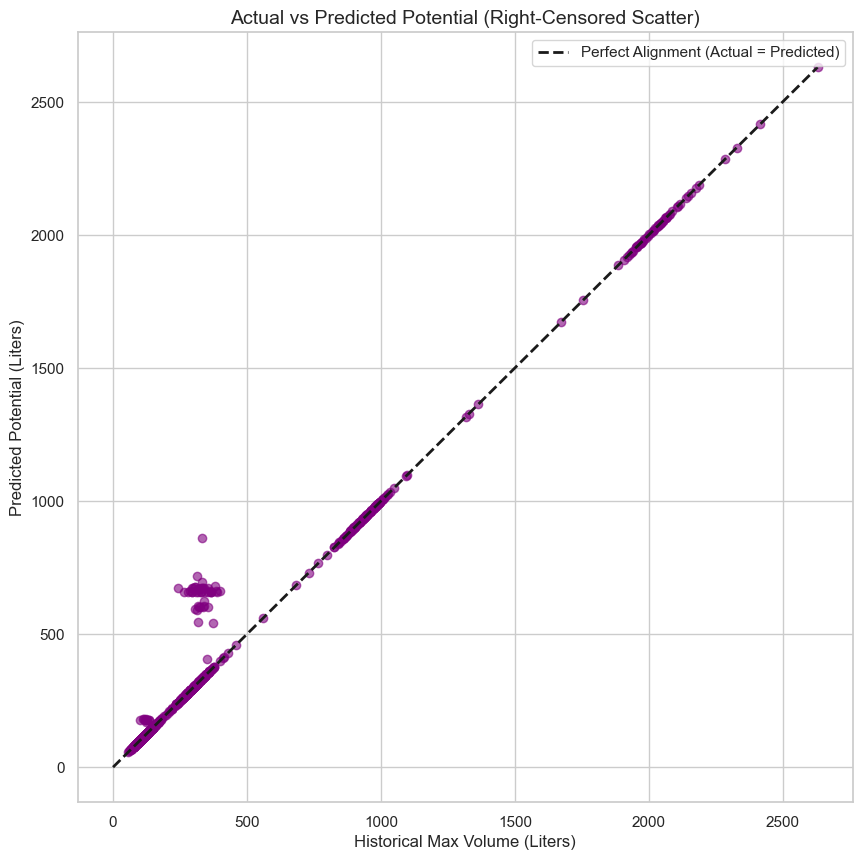

In [2]:
historical_max = abt.groupby("Outlet_ID")["Total_Volume"].max().reset_index(name="Historical_Max_Volume")
df_plot = preds.merge(historical_max, on="Outlet_ID", how="inner").sample(1000, random_state=42)

plt.figure(figsize=(10, 10))
plt.scatter(df_plot["Historical_Max_Volume"], df_plot["Maximum_Monthly_Liters"], alpha=0.6, color='purple')
max_val = max(df_plot["Historical_Max_Volume"].max(), df_plot["Maximum_Monthly_Liters"].max())
plt.plot([0, max_val], [0, max_val], 'k--', linewidth=2, label="Perfect Alignment (Actual = Predicted)")

plt.title("Actual vs Predicted Potential (Right-Censored Scatter)", fontsize=14)
plt.xlabel("Historical Max Volume (Liters)")
plt.ylabel("Predicted Potential (Liters)")
plt.legend()
plt.show()


### Plot 2: Feature Importance (The Heavyweight)

<Figure size 1000x800 with 0 Axes>

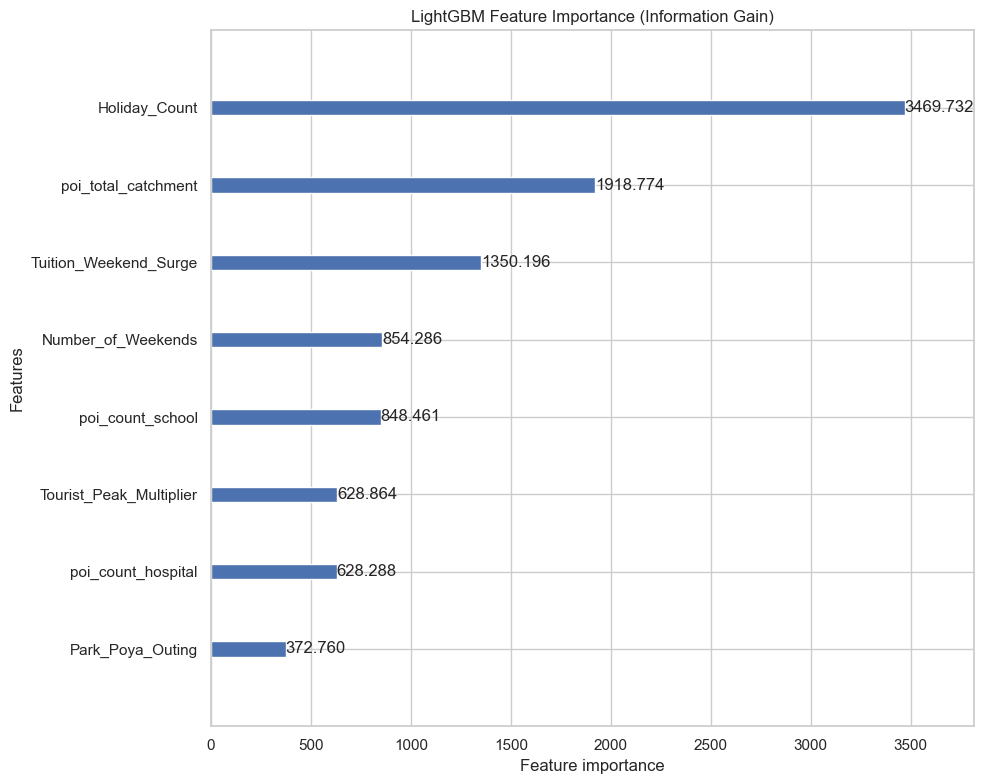

In [3]:
# To plot feature importance without retraining, we load the features into a quick proxy model
features = [
    "poi_total_catchment", "Tuition_Weekend_Surge", "Tourist_Peak_Multiplier", 
    "Sports_Big_Match_Spike", "Park_Poya_Outing", "Number_of_Weekends", "Holiday_Count",
    "poi_count_school", "poi_count_hospital", "Has_Youth_Catchment", "Has_Leisure_Catchment"
]
X_train = abt[abt['Is_Censored']==0][features].fillna(0)
y_train = abt[abt['Is_Censored']==0]['Total_Volume']

model = lgb.LGBMRegressor(objective='quantile', alpha=0.90, n_estimators=50, random_state=42, verbose=-1)
model.fit(X_train, y_train)

plt.figure(figsize=(10, 8))
lgb.plot_importance(model, max_num_features=15, title="LightGBM Feature Importance (Information Gain)", importance_type='gain', figsize=(10,8))
plt.tight_layout()
plt.show()


### Plot 3: The Growth Gap Map (Business Execution)

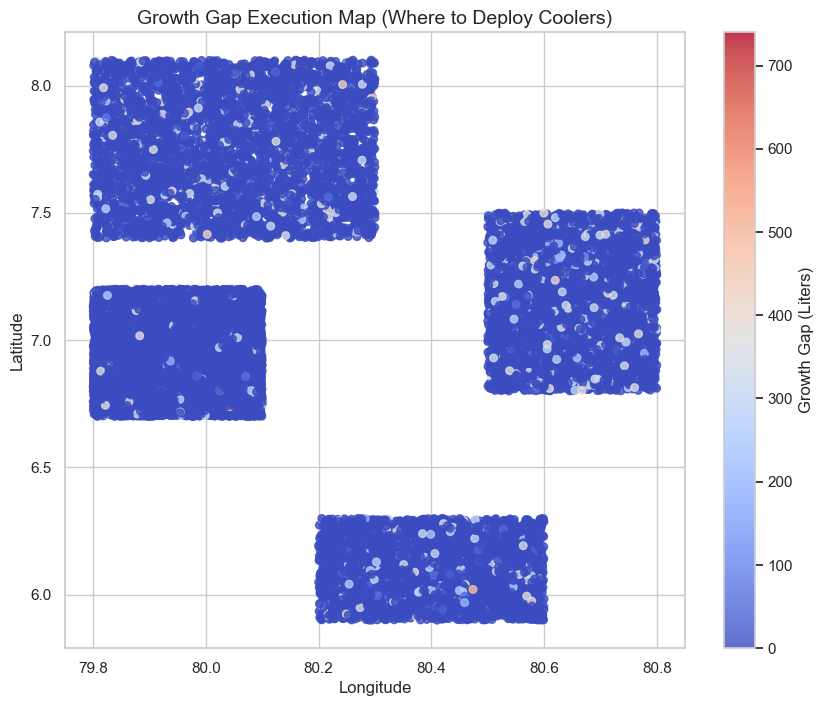

In [4]:
coords = pd.read_parquet('../data/silver/outlet_coordinates_clean.parquet')
df_map = preds.merge(historical_max, on="Outlet_ID", how="inner").merge(coords, on="Outlet_ID", how="inner")
df_map['Growth_Gap'] = df_map['Maximum_Monthly_Liters'] - df_map['Historical_Max_Volume']

plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_map['Longitude'], df_map['Latitude'], c=df_map['Growth_Gap'], cmap='coolwarm', alpha=0.8, s=30)
plt.colorbar(scatter, label='Growth Gap (Liters)')
plt.title("Growth Gap Execution Map (Where to Deploy Coolers)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()
